# Análisis Univariable — Admisiones de Posgrado

**Autor:** SCO

**Fecha:** 2026-08-19

**Descripción:**
Notebook 1 del Issue #3 "Análisis Exploratorio de Datos (EDA)". El Issue exige un
EDA completo dividido en tres notebooks: (1) análisis **univariable**, (2) análisis
bivariable y (3) análisis multivariable. Este notebook cubre únicamente el análisis
**univariable**.

Se trabaja sobre el dataset preparado en el Issue #2
(`data/02_intermediate/Admission_Predict.parquet`). Para cada atributo se
caracteriza: tipo de dato, naturaleza, valores nulos, valores únicos, duplicados,
distribución, estadística descriptiva y posibles problemas de calidad. También se
evalúa la utilidad de cada variable para el proyecto y se documentan reglas de
validación y transformaciones futuras.

Es un análisis **descriptivo y de diagnóstico**: no se imputan nulos, no se eliminan
outliers ni duplicados, no se escala, no se hace encoding ni feature engineering y
no se entrena ningún modelo.

## 📚 Import libraries

In [1]:
# librerías base para ciencia de datos
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 💾 Load data

Lectura **reproducible** e **inmutable** del dataset preparado: se localiza la raíz
del repositorio (buscando `pyproject.toml`) y se lee el Parquet tipado producido por
el Issue #2. No se modifica ni el Parquet ni el CSV RAW.

In [2]:
def find_repo_root(start: Path) -> Path:
    """Localiza la raíz del repositorio subiendo hasta encontrar `pyproject.toml`."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del repositorio (pyproject.toml).")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"

admission_df = pd.read_parquet(DATA_PATH)

admission_df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## 👷 Preparación de datos y perfil del dataset

Este notebook **no transforma los datos**: es un análisis de lectura. El perfil que
sigue describe el dataset tal cual fue entregado por el Issue #2, para caracterizar
cada variable antes de decidir cualquier preparación en etapas posteriores.

### Perfil general del dataset

In [3]:
print(f"Shape (filas, columnas): {admission_df.shape}")
print(f"Columnas: {list(admission_df.columns)}")
print()
admission_df.info()

Shape (filas, columnas): (623, 8)
Columnas: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          612 non-null    Int64  
 1   TOEFL Score        604 non-null    Int64  
 2   University Rating  617 non-null    Int64  
 3   SOP                607 non-null    float64
 4   LOR                615 non-null    float64
 5   CGPA               621 non-null    float64
 6   Research           594 non-null    Int64  
 7   Chance of Admit    623 non-null    float64
dtypes: Int64(4), float64(4)
memory usage: 41.5 KB


El dataset tiene **623 filas y 8 columnas** (7 features + el target
`Chance of Admit`). Los tipos respetan la corrección del Issue #2: 4 columnas
enteras con dtype nullable `Int64` (`GRE Score`, `TOEFL Score`, `University Rating`,
`Research`) y 4 continuas `float64` (`SOP`, `LOR`, `CGPA`, `Chance of Admit`).
No hay columnas de texto, fecha ni booleano: el dataset es 100 % numérico.

### Valores nulos

In [4]:
# Conteo documentado en el Issue #2, para verificar que el Parquet coincide.
documented_nulls = {
    "GRE Score": 11,
    "TOEFL Score": 19,
    "University Rating": 6,
    "SOP": 16,
    "LOR": 8,
    "CGPA": 2,
    "Research": 29,
    "Chance of Admit": 0,
}

actual_nulls = admission_df.isna().sum()
total_rows = len(admission_df)

null_df = pd.DataFrame(
    {
        "nulos": actual_nulls,
        "nulos (%)": (actual_nulls / total_rows * 100).round(2),
        "documentado (Issue #2)": pd.Series(documented_nulls),
    }
)
null_df["coincide"] = null_df["nulos"] == null_df["documentado (Issue #2)"]

null_df

,nulos,nulos (%),documentado (Issue #2),coincide
GRE Score,11,1.77,11,True
TOEFL Score,19,3.05,19,True
University Rating,6,0.96,6,True
SOP,16,2.57,16,True
LOR,8,1.28,8,True
CGPA,2,0.32,2,True
Research,29,4.65,29,True
Chance of Admit,0,0.00,0,True


**7 de 8 columnas** tienen valores faltantes; solo `Chance of Admit` está
completa. La columna con más nulos es `Research` (29, 4.65 %) y la que menos,
`CGPA` (2, 0.32 %). El conteo coincide exactamente con el documentado en el
Issue #2 (columna `coincide` en `True`). **No se imputan ni se eliminan registros**;
la estrategia de tratamiento se define en una etapa posterior.

### Filas y columnas duplicadas

In [5]:
n_rows = len(admission_df)
n_dup_rows = int(admission_df.duplicated().sum())
n_unique_rows = int(admission_df.drop_duplicates().shape[0])
n_dup_cols = int(admission_df.columns.duplicated().sum())

print(f"Filas totales: {n_rows}")
print(f"Filas duplicadas (exactas, conservando la primera): {n_dup_rows}")
print(f"Filas únicas: {n_unique_rows}")
print(f"Columnas con nombre duplicado: {n_dup_cols}")

Filas totales: 623
Filas duplicadas (exactas, conservando la primera): 152
Filas únicas: 471
Columnas con nombre duplicado: 0


Hay **152 filas duplicadas exactas** (≈24.4 % del dataset); tras descartar
duplicados quedan **471 filas únicas**. No hay nombres de columna duplicados.

La duplicación es un problema de calidad relevante: infla la frecuencia de ciertos
perfiles y, si el split train/test se hace sin deduplicar, la misma fila podría
aparecer en ambos conjuntos (leakage). Se documenta para resolver en la etapa de
preparación; aquí **no se elimina nada**.

### Clasificación de variables

In [6]:
classif_df = pd.DataFrame(
    {
        "dtype": admission_df.dtypes,
        "nulos": admission_df.isna().sum(),
        "únicos": [admission_df[c].nunique(dropna=True) for c in admission_df.columns],
        "mínimo": [admission_df[c].min() for c in admission_df.columns],
        "máximo": [admission_df[c].max() for c in admission_df.columns],
    }
)

classif_df

,dtype,nulos,únicos,mínimo,máximo
GRE Score,Int64,11,49,290.00,340.00
TOEFL Score,Int64,19,29,92.00,120.00
University Rating,Int64,6,5,1.00,5.00
SOP,float64,16,9,1.00,5.00
LOR,float64,8,9,1.00,5.00
CGPA,float64,2,168,6.80,9.92
Research,Int64,29,2,0.00,1.00
Chance of Admit,float64,0,60,0.34,0.97


Clasificación conceptual (naturaleza) de cada variable, junto con el rango
**documentado** (en `data/01_raw/Informacion.txt`) y el rango **observado**
(calculado empíricamente):

| Variable | Naturaleza | Rango documentado | Rango observado |
| --- | --- | --- | --- |
| `GRE Score` | numérica discreta (puntaje entero) | 0–340 | 290–340 |
| `TOEFL Score` | numérica discreta (puntaje entero) | 0–120 | 92–120 |
| `University Rating` | categórica ordinal (1–5) | 0–5 | 1–5 |
| `SOP` | ordinal discreta (1.0–5.0, paso 0.5) | 0–5 | 1.0–5.0 |
| `LOR` | ordinal discreta (1.0–5.0, paso 0.5) | 0–5 | 1.0–5.0 |
| `CGPA` | numérica continua | 0–10 | 6.8–9.92 |
| `Research` | binaria (0/1) | 0 o 1 | 0/1 |
| `Chance of Admit` | numérica continua, acotada [0,1] — **TARGET** | 0–1 | 0.34–0.97 |

Los rangos documentados son **más amplios** que los observados; ningún valor viola
los límites documentados. Dato notable: `University Rating` documenta un posible 0,
pero solo se observan valores 1–5.

## 📊 Análisis de resultados y conclusiones

### Estadística descriptiva global

La siguiente tabla resume la estadística descriptiva de cada columna (excluyendo
nulos para las métricas de tendencia central y dispersión). Para las variables
ordinales/binaras (`University Rating`, `SOP`, `LOR`, `Research`) la media, skewness
y kurtosis son orientativas, no interpretables como en una variable continua.

In [7]:
def describe_variable(col: pd.Series) -> pd.Series:
    """Estadística descriptiva univariable de una columna numérica."""
    return pd.Series(
        {
            "count": col.count(),
            "nulos": col.isna().sum(),
            "nulos (%)": round(col.isna().mean() * 100, 2),
            "únicos": col.nunique(dropna=True),
            "mínimo": col.min(),
            "Q1": col.quantile(0.25),
            "mediana": col.median(),
            "Q3": col.quantile(0.75),
            "máximo": col.max(),
            "rango": col.max() - col.min(),
            "IQR": col.quantile(0.75) - col.quantile(0.25),
            "media": col.mean(),
            "desv. std": col.std(),
            "varianza": col.var(),
            "skewness": col.skew(),
            "kurtosis": col.kurtosis(),
        }
    )


summary_df = pd.DataFrame(
    {col: describe_variable(admission_df[col]) for col in admission_df.columns}
).T

summary_df.round(4)

,count,nulos,nulos (%),únicos,mínimo,Q1,mediana,Q3,máximo,rango,IQR,media,desv. std,varianza,skewness,kurtosis
GRE Score,612.0,11.0,1.77,49.0,290.00,309.00,317.00,326.00,340.00,50.00,17.00,317.0948,11.7478,138.0106,-0.0850,-0.7342
TOEFL Score,604.0,19.0,3.05,29.0,92.00,104.00,108.00,112.00,120.00,28.00,8.00,107.8659,6.1166,37.4132,0.0299,-0.6282
University Rating,617.0,6.0,0.96,5.0,1.00,2.00,3.00,4.00,5.00,4.00,2.00,3.1783,1.1540,1.3318,0.1247,-0.8973
SOP,607.0,16.0,2.57,9.0,1.00,3.00,3.50,4.00,5.00,4.00,1.00,3.4563,1.0050,1.0101,-0.3289,-0.6955
LOR,615.0,8.0,1.28,9.0,1.00,3.00,3.50,4.00,5.00,4.00,1.00,3.5179,0.8677,0.7529,-0.0983,-0.6350
CGPA,621.0,2.0,0.32,168.0,6.80,8.22,8.65,9.10,9.92,3.12,0.88,8.6377,0.5895,0.3476,-0.1097,-0.4457
Research,594.0,29.0,4.65,2.0,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.5505,0.4979,0.2479,-0.2036,-1.9652
Chance of Admit,623.0,0.0,0.00,60.0,0.34,0.64,0.73,0.84,0.97,0.63,0.20,0.7330,0.1422,0.0202,-0.3814,-0.3658


In [8]:
moda_df = pd.DataFrame(
    {"moda": [admission_df[c].mode(dropna=True).tolist() for c in admission_df.columns]},
    index=admission_df.columns,
)

moda_df

,moda
GRE Score,[312]
TOEFL Score,[110]
University Rating,[3]
SOP,[4.0]
LOR,[3.0]
CGPA,[8.56]
Research,[1]
Chance of Admit,[0.64]


Lectura global:

- Las 8 variables están **acotadas** y ninguna supera sus límites conceptuales.
- `CGPA` es la más "concentrada" relativa a su rango (desv. std 0.59 en un rango de
  ~3.1 puntos); `Chance of Admit` tiene desv. std 0.142 en [0,1].
- Casi todas las distribuciones son **casi simétricas** (|skewness| < 0.15), salvo
  `Chance of Admit` (skew ≈ −0.38) y `SOP` (skew ≈ −0.33), con asimetría negativa.
  `Research` (skew ≈ −0.20) es una variable **binaria**: su skewness no es
  informativo para caracterizar la distribución; en su caso conviene interpretar
  la proporción de 0 y 1 (ver su sección).
- Todas presentan **kurtosis negativa** (platicúrticas: más "aplanadas" que una
  normal), lo que sugiere que los valores se reparten de forma bastante uniforme
  dentro de cada rango.

A continuación se analiza cada variable por separado.

### 🎯 Target — `Chance of Admit`

`Chance of Admit` es la **variable objetivo** de un problema de **regresión**.
Es continua y está acotada conceptualmente en [0, 1] (es una probabilidad de
admisión). Características clave:

- **Sin nulos**: los 623 registros tienen target → habilita el aprendizaje supervisado.
- **Rango observado** 0.34–0.97, dentro de [0, 1] (sin violaciones de rango).
- **Centralidad**: media 0.733, mediana 0.730, moda 0.64.
- **Dispersión**: desv. std 0.142, IQR 0.20 (Q1 0.64 – Q3 0.84).
- **Forma**: asimetría negativa moderada (skew ≈ −0.38): la cola se extiende hacia
  los valores bajos, como se aprecia en el histograma (valores dispersos hasta 0.34)
  y en el boxplot (bigote inferior más largo que el superior).
- **Outliers potenciales**: con el criterio 1.5·IQR la cota inferior cae en 0.34
  (exactamente el mínimo); los 3 valores en 0.34 quedan en el límite por precisión de
  punto flotante y son valores bajos legítimos, no errores. No se eliminan.

In [9]:
describe_variable(admission_df["Chance of Admit"]).round(4).to_frame("Chance of Admit")

,Chance of Admit
count,623.0000
nulos,0.0000
nulos (%),0.0000
únicos,60.0000
mínimo,0.3400
Q1,0.6400
mediana,0.7300
Q3,0.8400
máximo,0.9700
rango,0.6300


In [10]:
def plot_distribution(col: pd.Series, title: str) -> None:
    """Histograma con densidad y boxplot para una variable numérica."""
    data = col.dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución de {title}")
    axes[0].set_xlabel(title)
    sns.boxplot(x=data, ax=axes[1])
    axes[1].set_title(f"Boxplot de {title}")
    axes[1].set_xlabel(title)
    fig.tight_layout()
    plt.show()


def iqr_outliers(col: pd.Series) -> pd.DataFrame:
    """Detecta valores atípicos potenciales con el criterio 1.5*IQR (solo diagnóstico)."""
    data = col.dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return pd.DataFrame(
        {
            "Q1": [q1],
            "Q3": [q3],
            "IQR": [iqr],
            "cota inferior": [low],
            "cota superior": [high],
            "n bajo cota inferior": [int((data < low).sum())],
            "n sobre cota superior": [int((data > high).sum())],
        }
    )

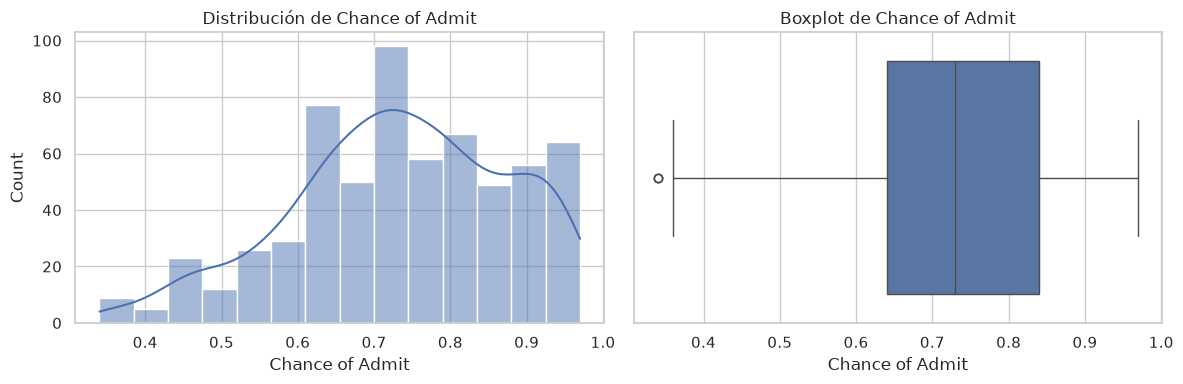

,Q1,Q3,IQR,cota inferior,cota superior,n bajo cota inferior,n sobre cota superior
0,0.64,0.84,0.2,0.34,1.14,3,0


In [11]:
plot_distribution(admission_df["Chance of Admit"], "Chance of Admit")

iqr_outliers(admission_df["Chance of Admit"]).round(4)

### `GRE Score`

Variable **numérica discreta** (puntaje entero del GRE).

- Rango observado 290–340 (documentado 0–340), 49 valores únicos.
- Centralidad: media 317.09, mediana 317, moda 312.
- Dispersión: desv. std 11.75, IQR 17 (Q1 309 – Q3 326).
- Forma: casi simétrica (skew ≈ −0.09) y platicúrtica (kurt ≈ −0.73), con los
  puntajes repartidos de forma amplia a lo largo del rango.
- Outliers: el criterio 1.5·IQR no señala ningún valor (cotas 283.5 y 351.5).
- Nulos: 11 (1.77 %).
- **Utilidad**: alta como indicador de aptitud académica; su relación con el target
  se validará en el análisis bivariable.

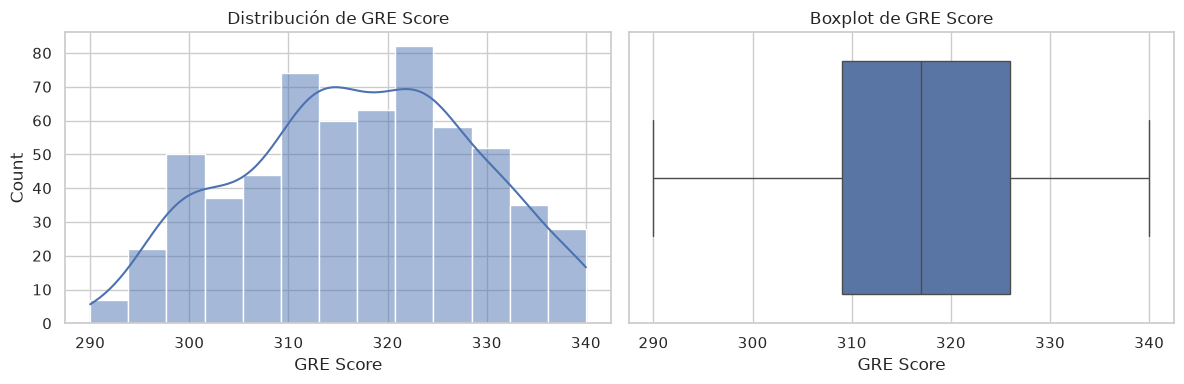

,Q1,Q3,IQR,cota inferior,cota superior,n bajo cota inferior,n sobre cota superior
0,309.0,326.0,17.0,283.5,351.5,0,0


In [12]:
plot_distribution(admission_df["GRE Score"], "GRE Score")

iqr_outliers(admission_df["GRE Score"]).round(4)

### `TOEFL Score`

Variable **numérica discreta** (puntaje entero del TOEFL).

- Rango observado 92–120 (documentado 0–120), 29 valores únicos.
- Centralidad: media 107.87, mediana 108, moda 110.
- Dispersión: desv. std 6.12, IQR 8 (Q1 104 – Q3 112); menor variabilidad relativa
  que el GRE.
- Forma: simétrica (skew ≈ 0.03) y platicúrtica (kurt ≈ −0.63).
- Outliers: ninguno por 1.5·IQR (cota inferior 92, coincide con el mínimo).
- Nulos: 19 (3.05 %).
- **Utilidad**: alta; mide dominio de inglés, complementario al GRE.

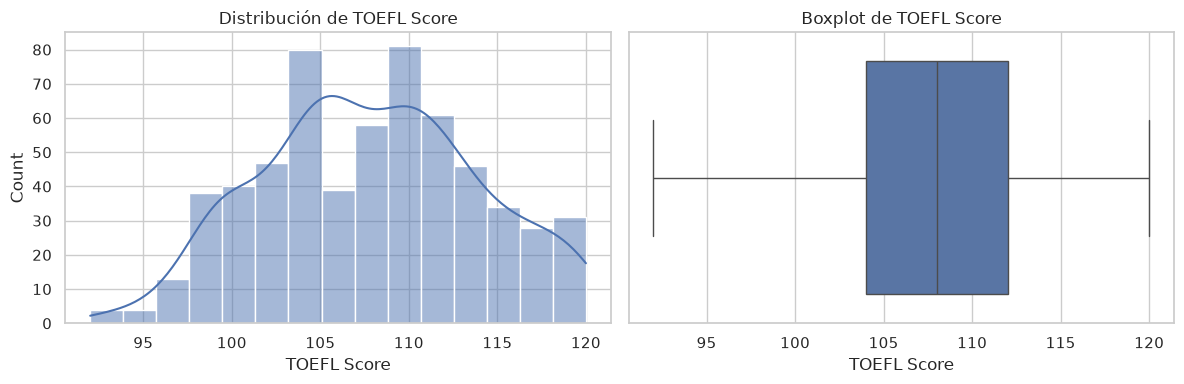

,Q1,Q3,IQR,cota inferior,cota superior,n bajo cota inferior,n sobre cota superior
0,104.0,112.0,8.0,92.0,124.0,0,0


In [13]:
plot_distribution(admission_df["TOEFL Score"], "TOEFL Score")

iqr_outliers(admission_df["TOEFL Score"]).round(4)

### `CGPA`

Variable **numérica continua** (promedio académico de pregrado).

- Rango observado 6.8–9.92 (documentado 0–10), 168 valores únicos (la de mayor
  cardinalidad).
- Centralidad: media 8.64, mediana 8.65, moda 8.56.
- Dispersión: desv. std 0.59, IQR 0.88 (Q1 8.22 – Q3 9.10).
- Forma: casi simétrica (skew ≈ −0.11), ligeramente platicúrtica (kurt ≈ −0.45).
- Outliers: un valor en 6.8 queda bajo la cota inferior 1.5·IQR (6.9); es un GPA
  bajo legítimo, no un error. No se elimina.
- Nulos: 2 (0.32 %).
- **Utilidad**: muy alta; es un resumen directo del rendimiento académico.

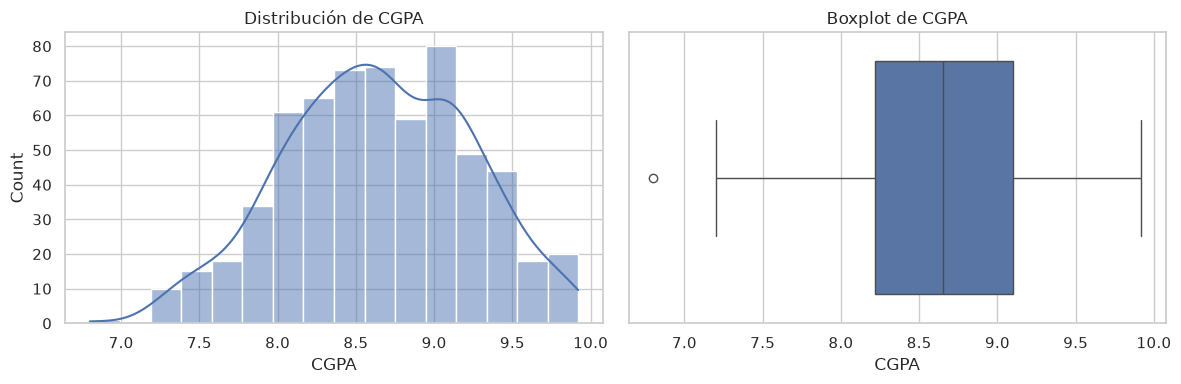

,Q1,Q3,IQR,cota inferior,cota superior,n bajo cota inferior,n sobre cota superior
0,8.22,9.1,0.88,6.9,10.42,1,0


In [14]:
plot_distribution(admission_df["CGPA"], "CGPA")

iqr_outliers(admission_df["CGPA"]).round(4)

### `University Rating`

Variable **categórica ordinal** (1–5), almacenada como entero.

- Frecuencias: 1 → 33, 2 → 158, 3 → 200, 4 → 118, 5 → 108.
- Centralidad: mediana y moda en 3, media 3.18; concentrada en ratings 2–4.
- No se observa el valor 0 pese a que la documentación indica rango 0–5.
- Nulos: 6 (0.96 %).
- **Utilidad**: moderada-alta; un rating ordinal que debería tratarse como ordinal
  en lugar de numérico puro.

In [15]:
def plot_counts(col: pd.Series, title: str) -> None:
    """Gráfico de barras de frecuencias para una variable discreta/ordinal/binaria."""
    data = col.dropna()
    order = sorted(data.unique().tolist())
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.countplot(x=data, order=order, ax=ax)
    ax.set_title(f"Frecuencias de {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Frecuencia")
    for container in ax.containers:
        ax.bar_label(container)
    fig.tight_layout()
    plt.show()

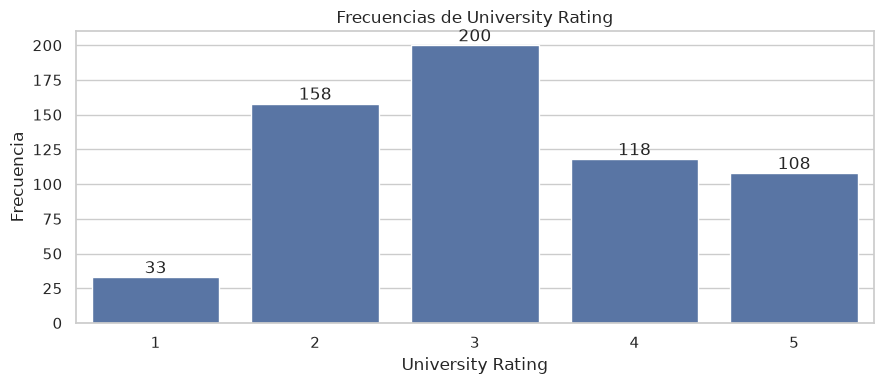

University Rating
1        33
2       158
3       200
4       118
5       108
<NA>      6
Name: count, dtype: Int64

In [16]:
plot_counts(admission_df["University Rating"], "University Rating")

admission_df["University Rating"].value_counts(dropna=False).sort_index()

### `SOP`

Variable **ordinal discreta** (fortaleza de la carta de propósito), escala
1.0–5.0 en pasos de 0.5 (9 niveles), almacenada como `float64`.

- Frecuencias: 1.0 → 6, 1.5 → 31, 2.0 → 52, 2.5 → 60, 3.0 → 91, 3.5 → 108,
  4.0 → 111, 4.5 → 87, 5.0 → 61.
- Centralidad: media 3.46, mediana 3.5, moda 4.0; ligera asimetría negativa
  (skew ≈ −0.33) — hay más calificaciones altas.
- Outliers: los 6 valores en 1.0 quedan bajo la cota 1.5·IQR (1.5), pero son
  categorías legítimas de la escala ordinal, no anomalías.
- Nulos: 16 (2.57 %).
- **Utilidad**: moderada; las notas de SOP son subjetivas y suelen aportar menos
  señal que métricas objetivas (GRE/TOEFL/CGPA).

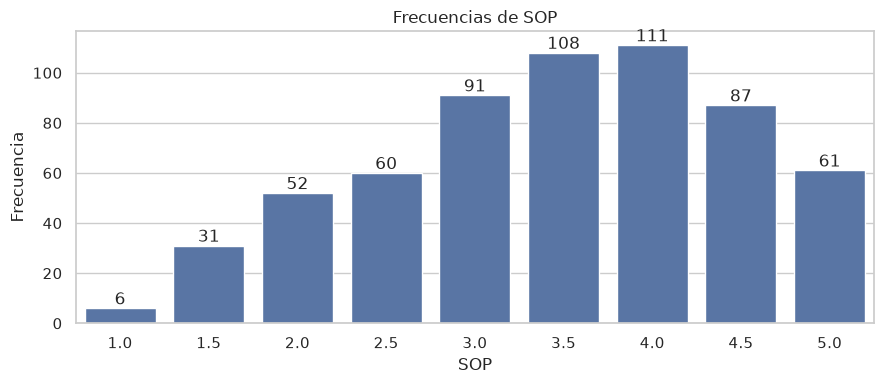

SOP
1.0      6
1.5     31
2.0     52
2.5     60
3.0     91
3.5    108
4.0    111
4.5     87
5.0     61
NaN     16
Name: count, dtype: int64

In [17]:
plot_counts(admission_df["SOP"], "SOP")

admission_df["SOP"].value_counts(dropna=False).sort_index()

### `LOR`

Variable **ordinal discreta** (fortaleza de la carta de recomendación), escala
1.0–5.0 en pasos de 0.5 (9 niveles), almacenada como `float64`.

- Frecuencias: 1.0 → 1, 1.5 → 7, 2.0 → 45, 2.5 → 58, 3.0 → 137, 3.5 → 115,
  4.0 → 118, 4.5 → 77, 5.0 → 57.
- Centralidad: media 3.52, mediana 3.5, moda 3.0; casi simétrica (skew ≈ −0.10).
- Outliers: un único valor en 1.0 queda bajo la cota 1.5·IQR (1.5); es una categoría
  legítima, no un error.
- Nulos: 8 (1.28 %).
- **Utilidad**: moderada, similar a `SOP`.

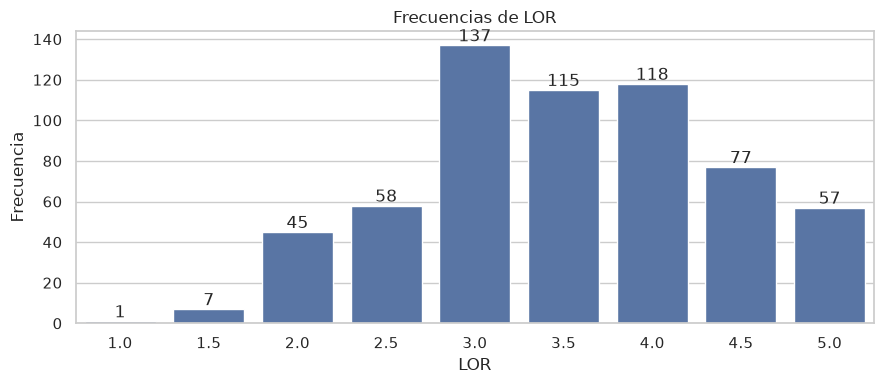

LOR
1.0      1
1.5      7
2.0     45
2.5     58
3.0    137
3.5    115
4.0    118
4.5     77
5.0     57
NaN      8
Name: count, dtype: int64

In [18]:
plot_counts(admission_df["LOR"], "LOR")

admission_df["LOR"].value_counts(dropna=False).sort_index()

### `Research`

Variable **binaria** (0 = sin experiencia en investigación, 1 = con
experiencia).

- Frecuencias: 0 → 267, 1 → 327 (≈55 % con experiencia); media 0.55.
- Nulos: 29 (4.65 %) — la mayor proporción de nulos del dataset.
- **Utilidad**: moderada; es una señal dicotómica útil que puede combinarse con
  otras variables. La imputación de sus 29 nulos será una decisión relevante en la
  etapa de preparación.

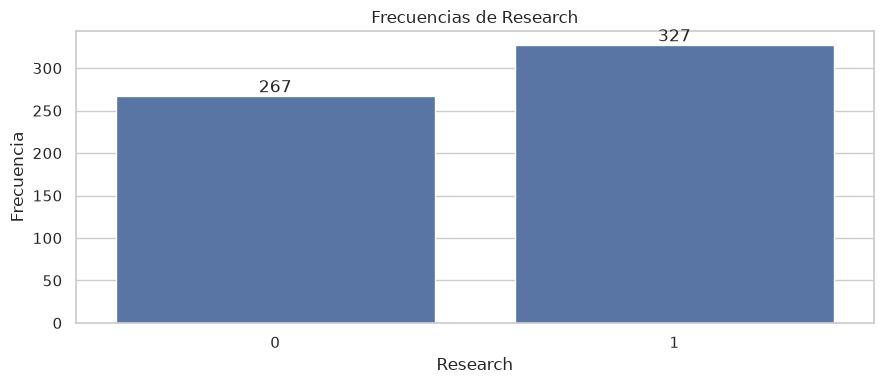

Research
0       267
1       327
<NA>     29
Name: count, dtype: Int64

In [19]:
plot_counts(admission_df["Research"], "Research")

admission_df["Research"].value_counts(dropna=False).sort_index()

## 💡 Propuestas e ideas

### Reglas de validación derivables del análisis

| Variable | Regla propuesta |
| --- | --- |
| `GRE Score` | entero entre 260 y 340 (observado 290–340) |
| `TOEFL Score` | entero entre 92 y 120 (observado; documentado 0–120) |
| `University Rating` | entero ordinal en {1, 2, 3, 4, 5} |
| `SOP` | valor en {1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0} |
| `LOR` | valor en {1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0} |
| `CGPA` | real entre 0 y 10 (observado 6.8–9.92) |
| `Research` | binaria en {0, 1} |
| `Chance of Admit` | real en [0, 1] |

### Transformaciones futuras a considerar (NO aplicadas aquí)

- **Deduplicación** de las 152 filas duplicadas (o manejo explícito en el split
  train/test para evitar leakage).
- **Imputación de nulos** a definir según el patrón de cada variable (media/mediana
  para numéricas, moda para ordinales/binaria, o descarte selectivo).
- **Tratamiento ordinal** de `University Rating`, `SOP` y `LOR` (decisión ordinal vs
  numérico según el impacto en el modelo).
- **Escalado/normalización** de `GRE Score`, `TOEFL Score` y `CGPA` si el modelo lo
  requiere (p. ej. modelos basados en distancia).
- Para el target acotado [0,1] evaluar, en etapa de modelado, si conviene una
  transformación (logit) o un modelo apto para respuesta acotada (regresión beta).

### Evidencia para una heurística / baseline (etapa posterior)

- El target está completo y acotado en [0,1] → problema de regresión supervisada
  bien definido.
- **Baseline trivial** = predecir siempre la media del target (0.733); su error
  esperado es la desviación estándar (RMSE ≈ 0.142), consistente con el baseline
  documentado en el Issue #1. La evaluación formal corresponde a una etapa posterior.
- Todas las features son numéricas con escalas y rangos conocidos: una heurística
  simple futura podría ser una **combinación ponderada** de `GRE Score`, `TOEFL
  Score`, `CGPA`, `University Rating` y `Research` (las variables de mayor señal
  objetiva), reescalada al intervalo [0,1]. Este notebook deja identificada esa
  evidencia univariable; **no se implementa ni evalúa** ningún modelo aquí.

## 📖 Referencias

- Issue #2 — *Exploración inicial de datos*:
  `notebooks/2-exploration/02.1-SCO_data_exploration-2026_08_19.ipynb`.
- `data/01_raw/Informacion.txt` — descripción del dataset y sus variables.
- Zapata, J. R. — *Análisis exploratorio de datos* (referencia del curso):
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/>.
- Documentación de pandas (dtypes nullable, `describe`, `skew`, `kurtosis`).
- Documentación de seaborn (`histplot`, `boxplot`, `countplot`).